## Lab 2 -Pitfalls of retrieval - when simple vector search fails!

In [67]:
!pip install langchain-text-splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter, SentenceTransformersTokenTextSplitter

def load_chroma(filename, collection_name, embedding_function):

    # Read PDF
    reader = PdfReader(filename)
    pdf_texts = [page.extract_text().strip() for page in reader.pages]

    # Remove empty pages
    pdf_texts = [text for text in pdf_texts if text]

    # Character splitting
    character_splitter = RecursiveCharacterTextSplitter(
        separators=["\n\n", "\n", ". ", " ", ""],
        chunk_size=1000,
        chunk_overlap=0
    )

    character_split_texts = character_splitter.split_text(
        "\n\n".join(pdf_texts)
    )

    # Token splitting
    token_splitter = SentenceTransformersTokenTextSplitter(
        chunk_overlap=0,
        tokens_per_chunk=256
    )

    token_split_texts = []

    for text in character_split_texts:
        token_split_texts.extend(
            token_splitter.split_text(text)
        )

    # Create Chroma collection
    chroma_client = chromadb.Client()

    try:
        chroma_client.delete_collection(collection_name)
        print(f"Deleted existing collection: {collection_name}")
    except:
        pass

    collection = chroma_client.create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )

    # Add documents
    ids = [str(i) for i in range(len(token_split_texts))]

    collection.add(
        ids=ids,
        documents=token_split_texts
    )

    return collection

1.  **Using the file browser:** Click on the folder icon on the left sidebar to open the file browser. Then, click the 'Upload' icon (a paperclip pointing upwards) and select your `helper_utils.py` file from your local machine.
2.  **Using code (for files on Google Drive or GitHub):** If your `helper_utils.py` file is on Google Drive, you can mount your Drive and navigate to the file. If it's on GitHub, you can use `!wget` or `!git clone` to download it.

In [71]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
!pip install pypdf
from pypdf import PdfReader

embedding_function1 = SentenceTransformerEmbeddingFunction()

chroma_collection = load_chroma(filename='sample_data/2025_AnnualReport.pdf', collection_name='microsoft_annual_report_2022', embedding_function=embedding_function1)
print(chroma_collection)
chroma_collection.count()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Deleted existing collection: microsoft_annual_report_2022
Collection(name=microsoft_annual_report_2022)


315

In [82]:
# Fetch and print a snapshot of the first 10 records
data_snapshot = chroma_collection.peek()
content = chroma_collection.get(limit=5, include=['documents', 'metadatas','embeddings'])
print (content)

{'ids': ['0', '1', '2', '3', '4'], 'embeddings': array([[-0.03494143, -0.04444974,  0.04186342, ..., -0.03895711,
         0.02584319, -0.0435413 ],
       [ 0.02977196, -0.03655642,  0.00157468, ..., -0.11460619,
        -0.00285684, -0.05655612],
       [-0.08300593, -0.01058406,  0.00238173, ..., -0.01529303,
         0.01938143,  0.02364712],
       [-0.03098187,  0.03474726,  0.01231986, ..., -0.06952725,
         0.00700821,  0.01099445],
       [-0.02535081,  0.03968681,  0.01377447, ..., -0.06029424,
        -0.0052977 , -0.02139598]]), 'documents': ['dear shareholders, colleagues, customers, and partners : fifty years after our founding, microsoft is once again at the heart of a generational moment in technology as we find ourselves in the midst of the ai platform shift. more than any transformation before it, this generation of ai is radically changing every layer of the tech stack, and we are changing with it. across the company, we are accelerating our pace of innovation an

In [59]:
import umap
import numpy as np
from tqdm import tqdm

embeddings = chroma_collection.get(include=['embeddings'])['embeddings']
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [60]:
def project_embeddings(embeddings, umap_transform):
    umap_embeddings = np.empty((len(embeddings),2))
    for i, embedding in enumerate(tqdm(embeddings)):
        umap_embeddings[i] = umap_transform.transform([embedding])
    return umap_embeddings

In [61]:
projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

100%|██████████| 315/315 [00:01<00:00, 235.60it/s]


(np.float64(-1.6740930020809173),
 np.float64(8.596369141340256),
 np.float64(5.11953296661377),
 np.float64(10.852411842346191))

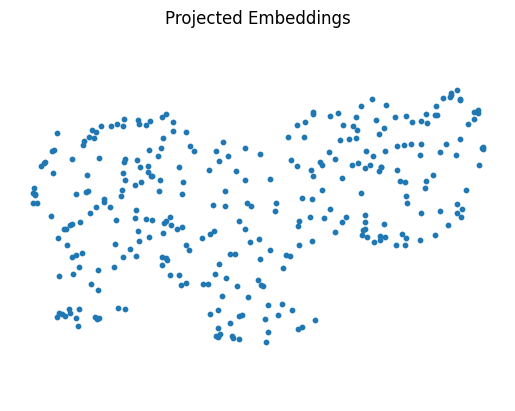

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10)
plt.gca().set_aspect('equal', 'datalim')
plt.title('Projected Embeddings')
plt.axis('off')

## Relevancy and Distraction

In [70]:
query = "What is the total revenue?"

results = chroma_collection.query(query_texts=query, n_results=5, include=['documents', 'embeddings'])
print(type(results))
print(len(results))
print(results)

retrieved_documents = results['documents'][0]

for document in results['documents'][0]:
    print(word_wrap(document))
    print('')

<class 'dict'>
8
{'ids': [['286', '254', '147', '166', '287']], 'embeddings': [array([[ 0.05554566, -0.02353525, -0.01119574, ..., -0.06783335,
        -0.01281472, -0.03712572],
       [-0.02331976, -0.02121263, -0.01808939, ..., -0.11291149,
        -0.00196688, -0.04734357],
       [-0.00864006, -0.0569366 ,  0.01177705, ..., -0.13106261,
        -0.05283823, -0.03457154],
       [-0.06799304, -0.04047695, -0.01693334, ..., -0.08130039,
         0.06248052, -0.05807864],
       [-0.00293235,  0.0055117 , -0.00601654, ..., -0.14083596,
         0.00037817, -0.06708744]])], 'documents': [['no sales to an individual customer or country other than the united states accounted for more than 10 % of revenue for fiscal years 2025, 2024, or 2023. revenue, classified by the major geographic areas in which our customers were located, was as follows : ( a ) includes billings to oems and certain multinational organizations because of the nature of these businesses and the impracticability of det

In [66]:
query_embedding = embedding_function([query])[0]
retrieved_embeddings = results['embeddings'][0]


print(type(query_embedding))
print(len(query_embedding))
print(query_embedding.shape)

print(type(retrieved_embeddings))
print(len(retrieved_embeddings))
print(retrieved_embeddings.shape)

projected_query_embedding = project_embeddings([query_embedding], umap_transform)
projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)


<class 'numpy.ndarray'>
384
(384,)
<class 'numpy.ndarray'>
5
(5, 384)


100%|██████████| 5/5 [00:00<00:00, 262.30it/s]


(np.float64(-1.6740930020809173),
 np.float64(8.596369141340256),
 np.float64(5.11953296661377),
 np.float64(10.852411842346191))

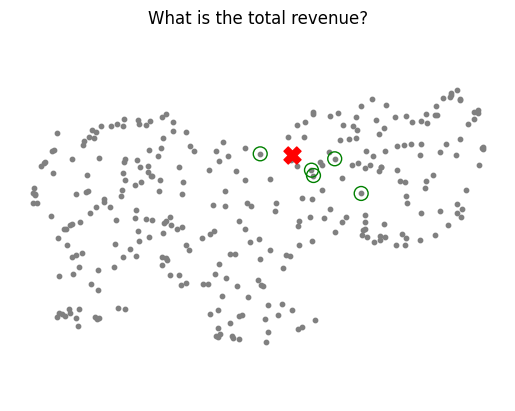

In [50]:
# Plot the projected query and retrieved documents in the embedding space
plt.figure()
plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10, color='gray')
plt.scatter(projected_query_embedding[:, 0], projected_query_embedding[:, 1], s=150, marker='X', color='r')
plt.scatter(projected_retrieved_embeddings[:, 0], projected_retrieved_embeddings[:, 1], s=100, facecolors='none', edgecolors='g')

plt.gca().set_aspect('equal', 'datalim')
plt.title(f'{query}')
plt.axis('off')

In [ ]:
query = "What is the strategy around artificial intelligence (AI) ?"
results = chroma_collection.query(query_texts=query, n_results=5, include=['documents', 'embeddings'])

retrieved_documents = results['documents'][0]

for document in results['documents'][0]:
    print(word_wrap(document))
    print('')

In [ ]:
query_embedding = embedding_function([query])[0]
retrieved_embeddings = results['embeddings'][0]

projected_query_embedding = project_embeddings([query_embedding], umap_transform)
projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)


In [ ]:
# Plot the projected query and retrieved documents in the embedding space
plt.figure()
plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10, color='gray')
plt.scatter(projected_query_embedding[:, 0], projected_query_embedding[:, 1], s=150, marker='X', color='r')
plt.scatter(projected_retrieved_embeddings[:, 0], projected_retrieved_embeddings[:, 1], s=100, facecolors='none', edgecolors='g')

plt.gca().set_aspect('equal', 'datalim')
plt.title(f'{query}')
plt.axis('off')

In [13]:
query = "What has been the investment in research and development?"
results = chroma_collection.query(query_texts=query, n_results=5, include=['documents', 'embeddings'])

retrieved_documents = results['documents'][0]

for document in results['documents'][0]:
    print(word_wrap(document))
    print('')

NameError: name 'chroma_collection' is not defined

In [ ]:
query_embedding = embedding_function([query])[0]
retrieved_embeddings = results['embeddings'][0]

projected_query_embedding = project_embeddings([query_embedding], umap_transform)
projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)


In [ ]:
# Plot the projected query and retrieved documents in the embedding space
plt.figure()
plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10, color='gray')
plt.scatter(projected_query_embedding[:, 0], projected_query_embedding[:, 1], s=150, marker='X', color='r')
plt.scatter(projected_retrieved_embeddings[:, 0], projected_retrieved_embeddings[:, 1], s=100, facecolors='none', edgecolors='g')

plt.gca().set_aspect('equal', 'datalim')
plt.title(f'{query}')
plt.axis('off')

In [ ]:
query = "What has Michael Jordan done for us lately?"
results = chroma_collection.query(query_texts=query, n_results=5, include=['documents', 'embeddings'])

retrieved_documents = results['documents'][0]

for document in results['documents'][0]:
    print(word_wrap(document))
    print('')

In [ ]:
query_embedding = embedding_function([query])[0]
retrieved_embeddings = results['embeddings'][0]

projected_query_embedding = project_embeddings([query_embedding], umap_transform)
projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)


In [ ]:
# Plot the projected query and retrieved documents in the embedding space
plt.figure()
plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10, color='gray')
plt.scatter(projected_query_embedding[:, 0], projected_query_embedding[:, 1], s=150, marker='X', color='r')
plt.scatter(projected_retrieved_embeddings[:, 0], projected_retrieved_embeddings[:, 1], s=100, facecolors='none', edgecolors='g')

plt.gca().set_aspect('equal', 'datalim')
plt.title(f'{query}')
plt.axis('off')